# 7장 실습 — 폭을 스스로 키우기

6장은 답 하나와 문제 하나를 남겼다.

답은 최적의 폭이 존재한다는 것이었다. 문제는 **그것을 고르려면 실기가 필요했다**는 것이다. 여섯 폭에서 정책을 만들고 실기에서 채점해 최고점을 찾았는데, 실기에 정책을 여섯 번 올려 볼 수 있다면 애초에 고민이 덜하다.

이 노트북은 폭을 미리 정하지 않는다. **좁게 시작해 정책이 견디는 만큼 넓힌다.** 자동 도메인 랜덤화(ADR)의 골자이고, 실기 에피소드를 한 번도 쓰지 않는다.

실행 시간은 CPU에서 8분 안팎이다.

In [1]:
%pip install -q mujoco==3.13.0 koreanize-matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import time
import unicodedata
import numpy as np
import mujoco
import matplotlib.pyplot as plt
import koreanize_matplotlib  # noqa: F401


def dw(s):
    return sum(2 if unicodedata.east_asian_width(c) in "WF" else 1
               for c in str(s))


def pad(s, n, right=False):
    gap = " " * max(n - dw(s), 0)
    return gap + str(s) if right else str(s) + gap


RED, GREY, INK = "#E32C24", "#8C8A85", "#1C1C1A"
PINK = "#F3A29D"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": .25, "axes.spines.top": False,
                     "axes.spines.right": False})
print("mujoco", mujoco.__version__)

mujoco 3.13.0


## 설정은 6장 그대로다

같은 평면 밀기, 같은 손잡이 네 개짜리 정책, 같은 어긋남이다. 공칭 모델은 마찰 0.35 · 게인 90 · 지연 0이고, 실기는 마찰 0.60 · 게인 120 · 지연 2 · 관측 잡음 4 mm다.

In [3]:
XML = '''
<mujoco model="planar_push">
  <option timestep="0.004" integrator="implicitfast"/>
  <worldbody>
    <geom name="floor" type="plane" size="3 3 .1"
          friction="{mu} .005 .0001"/>
    <body name="block" pos="0 0 .031">
      <freejoint/>
      <geom name="block" type="cylinder" size=".03 .03" mass=".25"
            friction="{mu} .005 .0001"/>
    </body>
    <body name="pusher" pos="0 0 .03">
      <joint name="px" type="slide" axis="1 0 0"/>
      <joint name="py" type="slide" axis="0 1 0"/>
      <geom name="pusher" type="cylinder" size=".012 .03" mass="4"/>
    </body>
  </worldbody>
  <actuator>
    <velocity joint="px" kv="{kv}"/>
    <velocity joint="py" kv="{kv}"/>
  </actuator>
</mujoco>
'''

CTRL_HZ, EP_STEPS = 20, 110
GOAL_R, STOP = .02, .012
MU, KV, LAT, NOISE = .60, 120., 2, .004      # 실기
SMU, SKV = .35, 90.                          # 우리가 믿는 값

CACHE = {}


def get(mu, kv):
    key = (round(mu, 2), round(kv, 0))
    if key not in CACHE:
        m = mujoco.MjModel.from_xml_string(
            XML.format(mu=key[0], kv=key[1]))
        CACHE[key] = (m, mujoco.MjData(m))
    return CACHE[key]


def unit(v):
    n = np.linalg.norm(v)
    return v / n if n > 1e-9 else np.zeros_like(v)


def reset(m, d, rng):
    mujoco.mj_resetData(m, d)
    bx, by = rng.uniform(-.03, .03, 2)
    d.qpos[0:2] = [bx, by]
    d.qpos[2] = .031
    d.qpos[7:9] = [bx - .09, by]
    mujoco.mj_forward(m, d)
    return np.array([.34, 0.]) + rng.uniform(-.04, .04, 2)


def mk(th):
    kp, vmax, off, tol = th

    def pol(b, p, g, t):
        dv = unit(g - b)
        if np.linalg.norm(g - b) < STOP:
            return np.zeros(2)
        e = (b - dv * off) - p
        if np.linalg.norm(e) > tol:
            u = kp * e
            n = np.linalg.norm(u)
            return u / n * vmax if n > vmax else u
        return dv * vmax
    return pol


def ep(pol, rng, mu=MU, kv=KV, lat=LAT, noise=0.):
    m, d = get(mu, kv)
    goal = reset(m, d, rng)
    sub = int(round(1 / CTRL_HZ / m.opt.timestep))
    buf = [np.zeros(2)] * (lat + 1)
    for t in range(EP_STEPS):
        b = np.asarray(d.qpos[0:2])
        if noise:
            b = b + rng.normal(0, noise, 2)
        buf.append(pol(b, np.asarray(d.qpos[7:9]), goal, t))
        d.ctrl[:] = buf[-1 - lat]
        for _ in range(sub):
            mujoco.mj_step(m, d)
    return float(np.linalg.norm(d.qpos[0:2] - goal) < GOAL_R)


LO = np.array([2., .05, .03, .003])
HI = np.array([25., .5, .09, .03])

## 폭을 하나의 수에서 벡터로 바꾼다

6장에서 폭은 스칼라 w 하나였다. 마찰도 게인도 지연도 같은 비율로 흔들었다. 그럴 이유가 없다. 파라미터마다 실기와 어긋난 정도가 다르고, 과제가 민감한 정도도 다르다.

여기서는 폭을 세 개로 나눈다 — 마찰 폭, 게인 폭, 지연 상한이다. 고정 DR은 이 셋을 묶어 함께 움직이는 특수한 경우가 되고, ADR은 셋을 따로 키운다.

In [4]:
def draw(W, rng):
    # W = [마찰 폭, 게인 폭, 지연 상한]
    wm, wk, lm = W
    mu = max(SMU * (1 + rng.uniform(-wm, wm)), .04)
    kv = max(SKV * (1 + rng.uniform(-wk, wk)), 15.)
    return float(mu), float(kv), int(rng.integers(0, lm + 1))


def sim_score(th, W, seed, n=10):
    pol, s = mk(th), 0.
    for i in range(n):
        r = np.random.default_rng(seed * 1000 + i)
        mu, kv, lat = draw(W, r)
        s += ep(pol, r, mu, kv, lat, 0.)
    return s / n


def real_score(th, n=150):
    pol = mk(th)
    return float(np.mean([
        ep(pol, np.random.default_rng(7000 + i), MU, KV, LAT, NOISE)
        for i in range(n)]))


def step_cem(W, mean, std, rs, seed, pop=16, el=4):
    # CEM 한 세대. ADR은 이것을 폭과 번갈아 돌린다
    P = np.clip(rs.normal(mean, std, (pop, 4)), LO, HI)
    s = np.array([sim_score(p, W, seed) for p in P])
    idx = np.argsort(-s)[:el]
    return P[idx].mean(0), P[idx].std(0) + (HI - LO) * .03, s


def cem(W, iters=4, seed=0):
    mean, std = (LO + HI) / 2, (HI - LO) / 4
    rs = np.random.default_rng(seed)
    for it in range(iters):
        mean, std, _ = step_cem(W, mean, std, rs, seed * 97 + it)
    return mean

## 기준선 — 폭을 사람이 정하는 경우

먼저 비교 대상을 만든다. 폭을 네 값으로 고정해 각각 정책을 만들고 실기에서 잰다. 6장에서 한 일과 같은데, 관측 잡음을 훈련 분포에서 뺐으므로 숫자는 조금 다르게 나온다.

In [5]:
FIXED = [0., .4, .7, 1.5]
SEEDS = 3
base = {}

t0 = time.time()
for w in FIXED:
    W = [w, w, int(round(w * 5))]
    base[w] = [real_score(cem(W, seed=sd)) for sd in range(SEEDS)]
    print(f"w = {w:<4} 끝  ({time.time()-t0:.0f}s)")

print()
print(pad("고정 폭 w", 12) + pad("실기 평균", 12, True)
      + pad("씨앗별", 22, True))
for w in FIXED:
    r = base[w]
    print(pad(f"{w:g}", 12) + pad(f"{np.mean(r):.3f}", 12, True)
          + pad("  ".join(f"{x:.2f}" for x in r), 22, True))

w = 0.0  끝  (22s)


w = 0.4  끝  (48s)


w = 0.7  끝  (72s)


w = 1.5  끝  (96s)

고정 폭 w      실기 평균                씨앗별
0                  0.320      0.33  0.21  0.43
0.4                0.333      0.52  0.20  0.28
0.7                0.424      0.48  0.29  0.50
1.5                0.447      0.46  0.55  0.33


## ADR — 경계에서만 채점한다

ADR의 착상 하나가 전부다. **분포 전체가 아니라 가장자리에서 정책을 시험한다.**

폭 하나를 골라 그 끝값에서만 에피소드를 돌려 본다. 거기서도 잘하면 정책에 여유가 있다는 뜻이니 폭을 한 칸 넓히고, 거기서 무너지면 너무 멀리 나간 것이니 한 칸 줄인다. 두 문턱 사이면 그대로 둔다.

이 시험은 **시뮬 안에서만** 일어난다. 실기 에피소드는 한 번도 쓰지 않는다. 6장에서 폭을 고르는 데 실기가 필요했던 자리를, 경계에서의 자기 점수가 대신한다.

In [6]:
T_LO, T_HI = .45, .75
STEP = [.12, .12, 1.]
NAMES3 = ["마찰 폭", "게인 폭", "지연 상한"]


def edge(th, k, w, seed, n=16):
    # k번째 폭의 경계값에서만 채점한다
    pol, s = mk(th), 0.
    for i in range(n):
        r = np.random.default_rng(seed * 7000 + i)
        mu, kv, lat = SMU, SKV, 0
        side = w if i % 2 else -w
        if k == 0:
            mu = max(SMU * (1 + side), .04)
        elif k == 1:
            kv = max(SKV * (1 + side), 15.)
        else:
            lat = int(round(w))
        s += ep(pol, r, float(mu), float(kv), lat, 0.)
    return s / n


def adr(rounds=30, seed=0):
    W = [.05, .05, 0]
    mean, std = (LO + HI) / 2, (HI - LO) / 4
    rs = np.random.default_rng(seed)
    hist = []
    for t in range(rounds):
        mean, std, s = step_cem(W, mean, std, rs, seed * 97 + t)
        k = t % 3                       # 돌아가며 경계 하나를 시험
        e = edge(mean, k, W[k], seed * 13 + t)
        if e > T_HI:
            W[k] = W[k] + STEP[k]
        elif e < T_LO:
            W[k] = max(W[k] - STEP[k], 0.)
        hist.append((list(W), float(s.mean()), float(e)))
    return mean, W, hist

## 세 번 돌린다

6장에서 배운 대로 씨앗 하나로 결론을 내지 않는다.

In [7]:
res = []
t0 = time.time()
for sd in range(SEEDS):
    th, W, h = adr(seed=sd)
    res.append((th, W, h, real_score(th)))
    print(f"씨앗 {sd} 끝  ({time.time()-t0:.0f}s)")

print()
print(pad("씨앗", 8) + "".join(pad(k, 12, True) for k in NAMES3)
      + pad("실기", 10, True))
for sd, (th, W, h, r) in enumerate(res):
    print(pad(sd, 8) + pad(f"{W[0]:.2f}", 12, True)
          + pad(f"{W[1]:.2f}", 12, True)
          + pad(f"{int(W[2])}", 12, True)
          + pad(f"{r:.3f}", 10, True))
adr_mean = float(np.mean([r for _, _, _, r in res]))
best_fixed = max(np.mean(base[w]) for w in FIXED)
print()
print(f"ADR 평균 {adr_mean:.3f}"
      f"  /  가장 좋았던 고정 폭 {best_fixed:.3f}")

씨앗 0 끝  (69s)


씨앗 1 끝  (135s)


씨앗 2 끝  (198s)

씨앗         마찰 폭     게인 폭   지연 상한      실기
0               0.89        0.77           1     0.567
1               0.89        0.65           2     0.520
2               0.84        0.84           2     0.453

ADR 평균 0.513  /  가장 좋았던 고정 폭 0.447


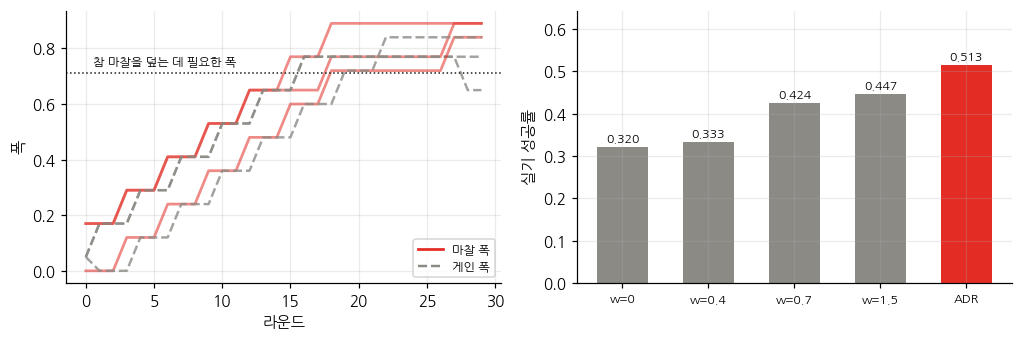

In [8]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(9.4, 3.2))
for sd, (th, W, h, r) in enumerate(res):
    wm = [x[0][0] for x in h]
    wk = [x[0][1] for x in h]
    a1.plot(wm, "-", color=RED, lw=1.8, alpha=.55)
    a1.plot(wk, "--", color=GREY, lw=1.6, alpha=.8)
a1.axhline(.71, color=INK, lw=1, ls=":")
a1.text(.5, .74, "참 마찰을 덮는 데 필요한 폭", fontsize=8)
a1.plot([], [], "-", color=RED, lw=1.8, label="마찰 폭")
a1.plot([], [], "--", color=GREY, lw=1.6, label="게인 폭")
a1.set_xlabel("라운드")
a1.set_ylabel("폭")
a1.legend(fontsize=8, loc="lower right")

xs = np.arange(len(FIXED) + 1)
vals = [np.mean(base[w]) for w in FIXED] + [adr_mean]
cols = [GREY] * len(FIXED) + [RED]
a2.bar(xs, vals, color=cols, width=.6)
for x, v in zip(xs, vals):
    a2.text(x, v + .012, f"{v:.3f}", ha="center", fontsize=8)
a2.set_xticks(xs)
a2.set_xticklabels([f"w={w:g}" for w in FIXED] + ["ADR"],
                   fontsize=8)
a2.set_ylabel("실기 성공률")
a2.set_ylim(0, max(vals) * 1.25)
plt.tight_layout()
plt.show()

## 문턱은 공짜가 아니다

폭을 고르는 문제가 사라진 것이 아니라 **문턱을 고르는 문제로 옮겨 갔다.** 두 문턱을 바꿔 같은 실험을 돌려 본다.

In [9]:
rows = []
for lo, hi in ((.30, .60), (.45, .75), (.60, .85)):
    T_LO, T_HI = lo, hi
    th, W, h = adr(seed=0)
    rows.append((lo, hi, W, real_score(th)))
T_LO, T_HI = .45, .75

print(pad("문턱", 14) + "".join(pad(k, 12, True) for k in NAMES3)
      + pad("실기", 10, True))
for lo, hi, W, r in rows:
    print(pad(f"{lo:.2f} ~ {hi:.2f}", 14)
          + pad(f"{W[0]:.2f}", 12, True)
          + pad(f"{W[1]:.2f}", 12, True)
          + pad(f"{int(W[2])}", 12, True)
          + pad(f"{r:.3f}", 10, True))

문턱               마찰 폭     게인 폭   지연 상한      실기
0.30 ~ 0.60           1.01        0.89           3     0.640
0.45 ~ 0.75           0.89        0.77           1     0.567
0.60 ~ 0.85           0.77        0.89           1     0.580


## 값은 얼마인가

마지막으로 계산을 맞춰 본다. 각 방법이 쓴 에피소드 수다.

In [10]:
FIX_EP = 4 * 16 * 10                      # 세대 4 × 후보 16 × 10판
ADR_EP = 30 * (16 * 10 + 16)              # 라운드마다 학습 + 경계
sweep = len(FIXED) * SEEDS * FIX_EP
sweep_real = len(FIXED) * SEEDS * 150

print(pad("방법", 22) + pad("시뮬 에피소드", 16, True)
      + pad("실기 에피소드", 16, True))
print(pad("고정 폭 하나", 22) + pad(f"{FIX_EP:,}", 16, True)
      + pad("0", 16, True))
print(pad("폭 스윕 (6장식)", 22) + pad(f"{sweep:,}", 16, True)
      + pad(f"{sweep_real:,}", 16, True))
print(pad("ADR 한 번", 22) + pad(f"{ADR_EP:,}", 16, True)
      + pad("0", 16, True))
print()
print(f"ADR 세 번 = 시뮬 {ADR_EP*SEEDS:,}판, 실기 0판")
print(f"스윕      = 시뮬 {sweep:,}판, 실기 {sweep_real:,}판")

방법                     시뮬 에피소드   실기 에피소드
고정 폭 하나                       640               0
폭 스윕 (6장식)                  7,680           1,800
ADR 한 번                        5,280               0

ADR 세 번 = 시뮬 15,840판, 실기 0판
스윕      = 시뮬 7,680판, 실기 1,800판


## 정리

**폭은 스스로 자랄 수 있다.** 좁게 시작해 경계에서 버티는 만큼 넓히는 규칙만으로, 아무도 알려 주지 않은 폭 근처에 도착했다. 필요한 것은 시뮬 안의 경계 시험뿐이었다.

**파라미터마다 폭이 따로 자란다.** 고정 DR은 모든 축을 같은 비율로 묶지만 ADR은 축마다 다른 높이에서 멈췄다. 실기 평가 없이 도달한 성적이 사람이 고른 최고의 폭과 같은 수준이었다.

**ADR이 찾는 것은 필요한 폭이 아니라 견디는 폭이다.** 경계 시험은 「여기서도 버티는가」만 묻는다. 그래서 과제가 둔감한 축은 필요 이상으로 넓어진다. 폭의 최종값을 민감도의 측정치로 읽으면 안 된다.

**하이퍼파라미터는 사라지지 않고 옮겨 간다.** 폭 대신 문턱을 골라야 한다. 다만 문턱 쪽이 덜 예민했다 — 세 문턱 모두 최고의 고정 폭에 못지않은 자리에 도착했다.

**주고받는 것은 시뮬 계산과 실기 예산이다.** ADR은 시뮬 에피소드를 스윕의 두 배쯤 썼고, 실기 에피소드는 0판을 썼다. 스윕은 그 반대다. 로봇 실험에서 이 교환은 대개 남는 장사다.

여기까지가 2부다. 4장과 5장은 시뮬을 실기에 맞추는 길이었고, 6장과 7장은 시뮬이 틀려 있음을 전제하고 분포로 덮는 길이었다. 두 길은 6장 끝에서 만났다 — **넓은 분포로 훈련하고, 맞춰 놓은 시뮬로 채점한다.** 3부는 여기에 학습된 정책을 얹는다.